In [400]:
import os

if 'main_dir' in globals():
    os.chdir(main_dir)

import pandas as pd
from utils.load_config import load_exp_config, get_value_from_fields, get_df_historical_data
from utils.load_data import (
    get_df_from_datetime_range
    )
import numpy as np

# %matplotlib inline

if os.getcwd().endswith("notebooks"):
    main_dir = os.getcwd()
    os.chdir("..")

In [401]:
os.getuid()

1000

In [530]:
DECAY_RATE = 1

start_datetime_str = "2024-11-04 15-18-27"
end_datetime_str = "2024-11-05 08-00-00"

# end_datetime_str = start_datetime_str = "2024-11-04 14-38-04"
# end_datetime_str = start_datetime_str = "2024-10-31 13-46-21"
# end_datetime_str = start_datetime_str = "2024-11-06 11-00-44" # Error of unchanged observation
# end_datetime_str = start_datetime_str = "2024-11-06 12-08-58"

# contain large buffer and reset buffer [true, false]
start_datetime_str = "2024-11-06 12-08-58"
end_datetime_str = "2024-11-06 13-27-35"

# contain large buffer and reset buffer [true, false] with bugfix on robot pursuit
start_datetime_str = "2024-11-07 08-38-32"
end_datetime_str = "2024-11-07 10-41-32"

# end_datetime_str = start_datetime_str = "2024-11-07 11-31-51"
end_datetime_str = start_datetime_str = "2024-11-09 14-13-27"

# Full run at server
start_datetime_str = "2024-11-07 14-35-44"
end_datetime_str = "2024-11-08 04-58-17"

# Test
end_datetime_str = start_datetime_str = "2024-11-08 21-30-23"
end_datetime_str = start_datetime_str = "2024-11-10 22-47-07"
end_datetime_str = start_datetime_str = "2024-11-11 07-38-36"
# end_datetime_str = start_datetime_str = "2024-11-09 20-42-20"


# end_datetime_str = start_datetime_str = "2024-11-08 21-30-23"

# end_datetime_str = start_datetime_str = "2024-11-10 14-18-31"
# end_datetime_str = start_datetime_str = "2024-11-10 16-46-24"


# Full SAC run at server
# start_datetime_str = "2024-11-08 22-32-12"
# end_datetime_str = "2024-11-09 06-05-21"

# SAC with Pushing Object
end_datetime_str = start_datetime_str = "2024-11-11 09-14-40"

df = get_df_from_datetime_range(start_datetime_str, 
                                end_datetime_str, 
                                decay_rate=DECAY_RATE,
                                max_iter=np.inf,
                                validity_check=False,
                                reload=False
                                )

df.head()

,time,running_objective,current_value,current_undiscounted_value,episode_id,iteration_id,task_name,step_id,phase,exploration,...,Image pixel 1193,Image pixel 1194,Image pixel 1195,Image pixel 1196,Image pixel 1197,Image pixel 1198,Image pixel 1199,absolute_path,exp_config,experiment_path
0,0.000,0.50,None,0.50,1,1,red,0,eval,False,...,0.423529,0.423529,0.423529,0.423529,0.423529,0.423529,0.423529,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...
1,0.000,0.70,None,1.20,1,1,red,1,eval,False,...,0.423529,0.423529,0.423529,0.423529,0.423529,0.423529,0.423529,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...
2,0.165,0.90,None,2.10,1,1,red,2,eval,False,...,0.423529,0.423529,0.423529,0.423529,0.423529,0.423529,0.423529,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...
3,0.330,0.95,None,3.05,1,1,red,3,eval,False,...,0.423529,0.423529,0.423529,0.423529,0.423529,0.423529,0.423529,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...
4,0.495,0.95,None,4.00,1,1,red,4,eval,False,...,0.423529,0.423529,0.423529,0.423529,0.423529,0.423529,0.423529,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...


In [531]:
exp_config = df.exp_config.values[0]
df = df.reindex()
def extract_columns(row):
    scenario = row.exp_config["scenario"]["_target_"].split(".")[-1]
    is_reset_buffer = row.exp_config["scenario"]["reset_rb_each_task"]
    buffer_size = row.exp_config["scenario"]["buffer_size"]
    learning_starts = row.exp_config["scenario"]["learning_starts"]
    controller = "SAC" if "sac" in scenario.lower() else "TD3"
    category = scenario[:scenario.find(controller)]
    return category, controller, is_reset_buffer, buffer_size, learning_starts
    
    # return pd.Series(data=[category, controller, is_reset_buffer, buffer_size], 
    #                  index=["category", "controller", "is_reset_buffer", "buffer_size"])

tmp = df.apply(extract_columns, axis=1, result_type='expand')
# tmp = df.exp_config.apply(extract_columns)
tmp.columns = ["category", "controller", "is_reset_buffer", "buffer_size", "learning_starts"]
df = pd.concat([df, tmp], axis=1)

In [532]:
df.head()

,time,running_objective,current_value,current_undiscounted_value,episode_id,iteration_id,task_name,step_id,phase,exploration,...,Image pixel 1198,Image pixel 1199,absolute_path,exp_config,experiment_path,category,controller,is_reset_buffer,buffer_size,learning_starts
0,0.000,0.50,None,0.50,1,1,red,0,eval,False,...,0.423529,0.423529,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,PushingObject,SAC,True,16000,1000
1,0.000,0.70,None,1.20,1,1,red,1,eval,False,...,0.423529,0.423529,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,PushingObject,SAC,True,16000,1000
2,0.165,0.90,None,2.10,1,1,red,2,eval,False,...,0.423529,0.423529,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,PushingObject,SAC,True,16000,1000
3,0.330,0.95,None,3.05,1,1,red,3,eval,False,...,0.423529,0.423529,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,PushingObject,SAC,True,16000,1000
4,0.495,0.95,None,4.00,1,1,red,4,eval,False,...,0.423529,0.423529,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,PushingObject,SAC,True,16000,1000


In [533]:
pd.Series(tmp.iloc[0], index=["category", "controller", "is_reset_buffer", "buffer_size"])

category           PushingObject
controller                   SAC
is_reset_buffer             True
buffer_size                16000
Name: 0, dtype: object

In [534]:
############################### Robot Pursuit is misisng ###############################
# group_df = df.groupby(["controller", "category", "task_name", "is_reset_buffer"]).last()
group_df = df.groupby(["controller", "category", "buffer_size"]).last()
group_df

,,,time,running_objective,current_value,current_undiscounted_value,episode_id,iteration_id,task_name,step_id,phase,exploration,...,Image pixel 1195,Image pixel 1196,Image pixel 1197,Image pixel 1198,Image pixel 1199,absolute_path,exp_config,experiment_path,is_reset_buffer,learning_starts
controller,category,buffer_size,,,,,,,,,,,,,,,,,,,,,
SAC,PushingObject,16000,4.62,0.696133,None,26.395887,1,84,yellow,626,eval,False,...,0.423529,0.423529,0.423529,0.423529,0.423529,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,True,1000


In [535]:
group_df.index.names, group_df.index[0]

(FrozenList(['controller', 'category', 'buffer_size']),
 ('SAC', 'PushingObject', 16000))

In [536]:
"\t".join([f"{a}:{b}" for a, b in list(zip(group_df.index.names, group_df.index[0]))])
# list(zip(group_df.index.names, group_df.index[0]))
group_df.index

MultiIndex([('SAC', 'PushingObject', 16000)],
           names=['controller', 'category', 'buffer_size'])

In [537]:
df = df.reset_index().set_index(group_df.index.names)
tmp_df = df.loc[group_df.index[0]]

In [538]:
from matplotlib import rc
# rc('font',**{'family':'sans-serif','sans-serif':['Helvelica']})
# for Palatino and other serif fonts use:
# rc('font',**{'family':'serif','serif':['Palatino']})
rc('text', usetex=False)

In [539]:
import matplotlib
print(matplotlib.matplotlib_fname())
matplotlib.__version__

/home/tcc/huyhoang/irlc_2025/regelum-playground-iclr/venv/lib/python3.10/site-packages/matplotlib/mpl-data/matplotlibrc


'3.9.2'

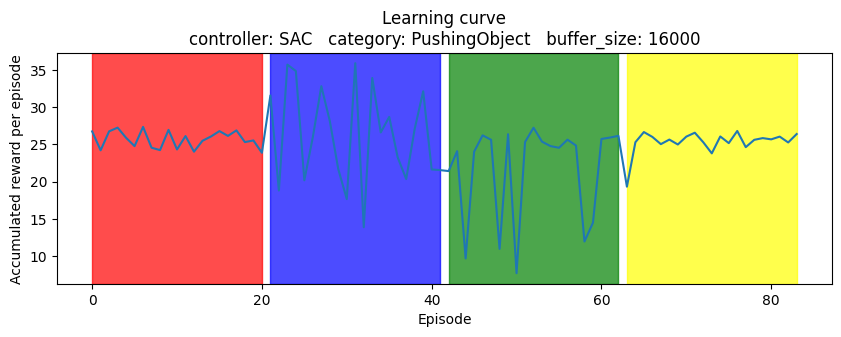

In [540]:
import matplotlib.pyplot as plt
# import matplotlib
# %matplotlib inline

def plot_learning_curve(index, index_names, df, title="Learning curve"):
    fig, ax = plt.subplots(figsize=(10,3))

    df = df.reset_index().set_index(index_names)
    tmp_df = df.loc[index]

    # Filter exploration actions
    tmp_df = tmp_df.loc[:, ["iteration_id", "step_id", "task_name", "current_undiscounted_value", "learning_starts", "phase"]]
    tmp_df = tmp_df[np.invert(np.logical_and(tmp_df.phase == "train", tmp_df.step_id <= tmp_df.learning_starts))]
    tmp_group_df = tmp_df.groupby("iteration_id")

    tmp_group_df = tmp_group_df.aggregate({
        "current_undiscounted_value": "last", 
        "task_name": "last",
        "step_id": "last"
        })
    
    # Re-assign index for ploting
    tmp_group_df = tmp_group_df.reset_index()
    tmp_group_df.iteration_id = tmp_group_df.reset_index().index
    tmp_group_df = tmp_group_df.set_index("iteration_id")

    tmp_group_df.plot(y="current_undiscounted_value", ax=ax)

    colors = ["red", "blue", "green", "yellow"]
    for t in tmp_group_df.task_name.unique():
        for c in colors:
            if c in t.lower():
                break

        tmp = tmp_group_df.reset_index().set_index("task_name").loc[t]
        ax.axvspan(tmp.iteration_id.values[0], tmp.iteration_id.values[-1], alpha=0.7, color=c)

    ax.set_xlabel('Episode')
    ax.set_ylabel('Accumulated reward per episode')
    ax.set_title(
        f'{title}\n' + 
        "   ".join([f"{a}: {b}" for a, b in list(zip(index_names, index))])
    )
    legend = ax.legend()
    legend.remove()


for id in group_df.index:
    plot_learning_curve(id, group_df.index.names, df)
    
# plot_learning_curve(group_df.index[1], group_df.index.names, df)
# plot_learning_curve(('SAC', 'LineFollowing', True), group_df.index.names, df)
# plot_learning_curve(('TD3', 'LineFollowing', False), group_df.index.names, df)
# plt.show()

In [564]:
if "eval" in df.phase.unique():
    analyse_group_df = df[df.phase == "eval"].reset_index().groupby(["task_name", "iteration_id"]).last()

    def is_solved_task(row):
        if row.category == "PushingObject":
            if row.task_name in ["blue", "yellow"]:
                return row.running_objective == 10
            
            if row.task_name in ["red", "green"]:
                return row.running_objective != -10

        return False

    def aggregate_function(series):
        sucess = np.sum(series)
        total = series.count()
        return "{:02.0f} / {:02.0f} = {:03.2f}".format(sucess, total, np.round(sucess / total, 2))

    analyse_group_df = analyse_group_df.reset_index()
    analyse_group_df["completion"] = analyse_group_df.apply(is_solved_task, axis=1)
    analyse_group_df = analyse_group_df.set_index(['controller', 'category', 'buffer_size'])

    pivot_table = pd.pivot_table(analyse_group_df.reset_index(), values="completion", columns=analyse_group_df.index,
                index=["task_name"], aggfunc=aggregate_function)
    
else:
    pivot_table = None

pivot_table

,"(SAC, PushingObject, 16000)"
task_name,
blue,12 / 21 = 0.57
green,16 / 21 = 0.76
red,21 / 21 = 1.00
yellow,00 / 21 = 0.00


,step_id,task_name,current_undiscounted_value,learning_starts,phase
iteration_id,,,,,
0,29,red,26.749010,1000,eval
1,59,red,24.204368,1000,eval
2,89,red,26.757938,1000,eval
3,119,red,27.256125,1000,eval
4,149,red,25.888462,1000,eval
...,...,...,...,...,...
79,506,yellow,25.845895,1000,eval
80,536,yellow,25.678711,1000,eval
81,566,yellow,26.050000,1000,eval


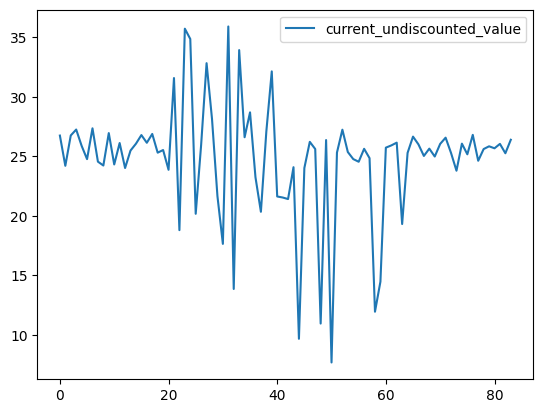

In [ ]:
tmp_df = df.loc[:, ["iteration_id", "step_id", "task_name", "current_undiscounted_value", "learning_starts", "phase"]]
tmp_df = tmp_df[np.invert(np.logical_and(tmp_df.phase == "train", tmp_df.step_id <= tmp_df.learning_starts))]
g = tmp_df.groupby("iteration_id").last()
g = g.reset_index()
g.iteration_id = g.reset_index().index
g.plot(y="current_undiscounted_value")
g.set_index("iteration_id")

In [ ]:
# df = df.reset_index().set_index(["controller", "category", "buffer_size", "task_name"])
# df[df.running_objective == 10].loc[['SAC']]

<Axes: xlabel='iteration_id'>

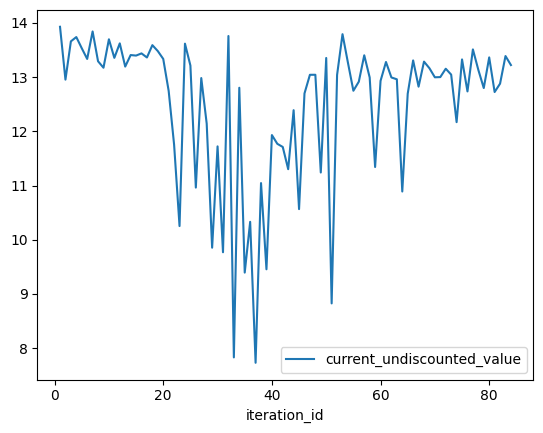

In [ ]:
df = df.reset_index().set_index(["controller", "category", "buffer_size", "task_name"])
df = df.reset_index().set_index(group_df.index.names)
tmp_df = df.loc[group_df.index]

tmp_group_df = tmp_df.loc[:, ["iteration_id", "step_id", "task_name", "current_undiscounted_value", "phase"]].groupby("iteration_id")
tmp_group_df = tmp_group_df.aggregate({
    "current_undiscounted_value": "mean", 
    "task_name": "last",
    "step_id": "last",
    "phase": "last"
    })
tmp_group_df[tmp_group_df.phase=="eval"].plot(y="current_undiscounted_value")

/home/tcc/huyhoang/irlc_2025/regelum-playground-iclr/venv/lib/python3.10/site-packages/pandas/plotting/_matplotlib/core.py:580: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = self.plt.figure(figsize=self.figsize)


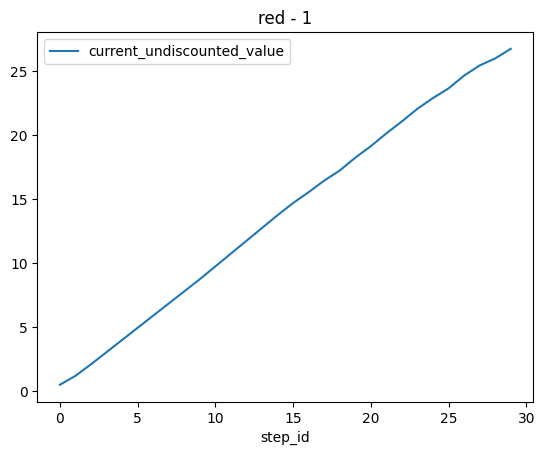

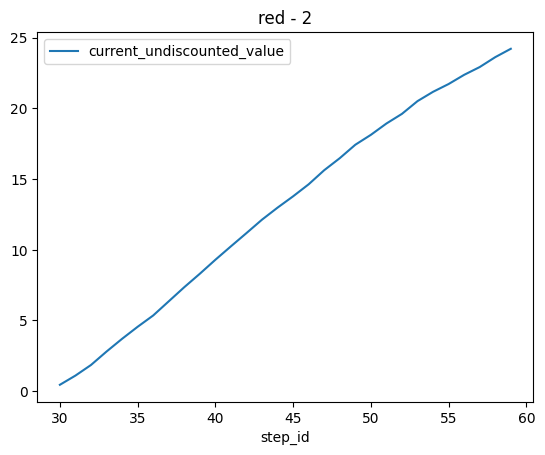

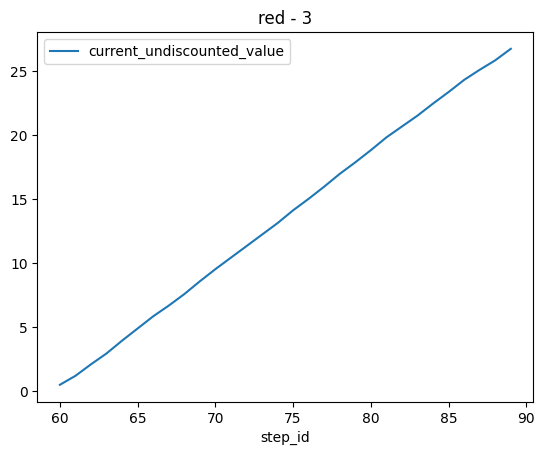

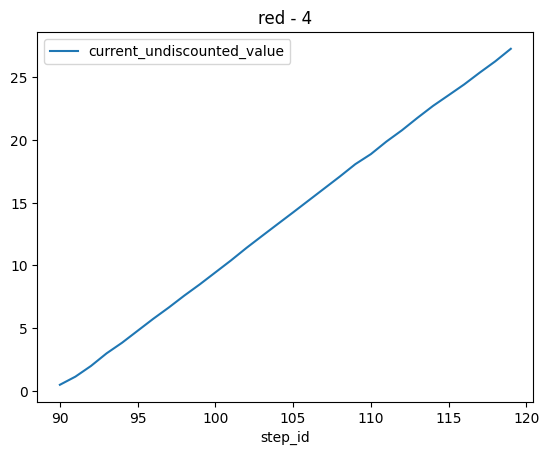

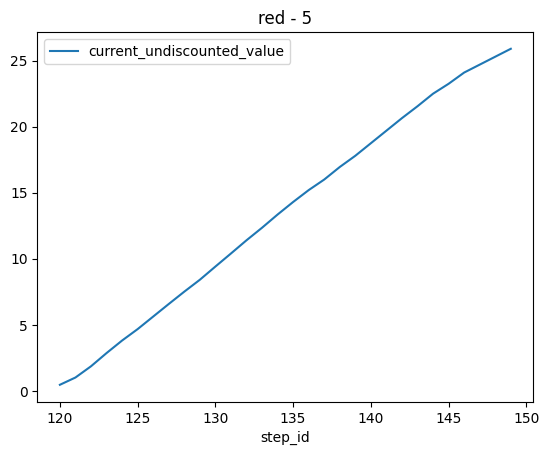

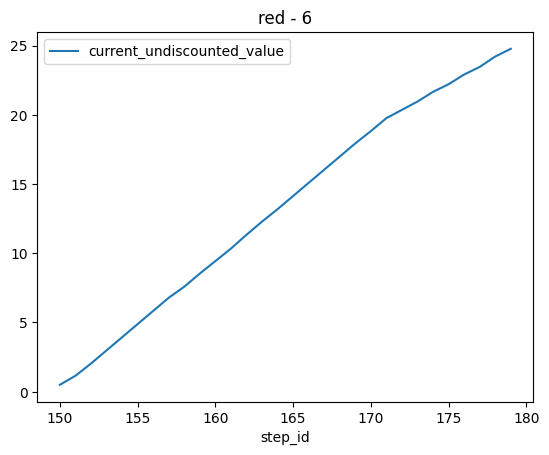

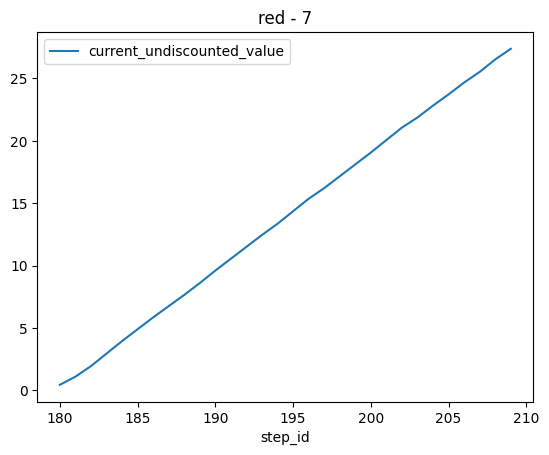

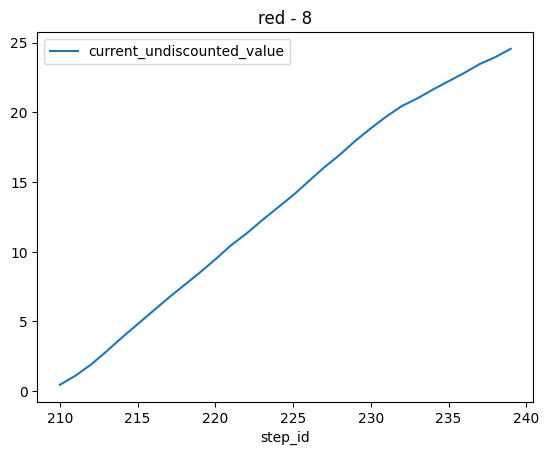

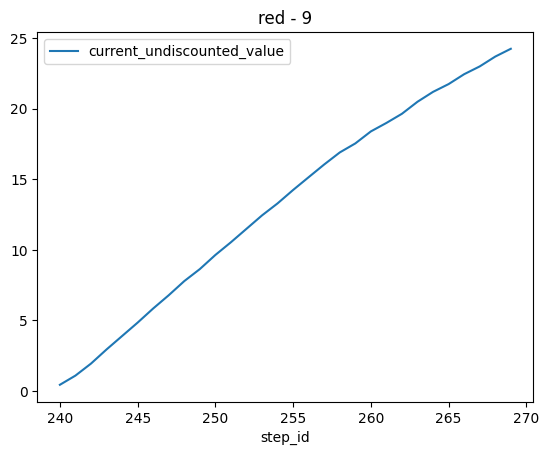

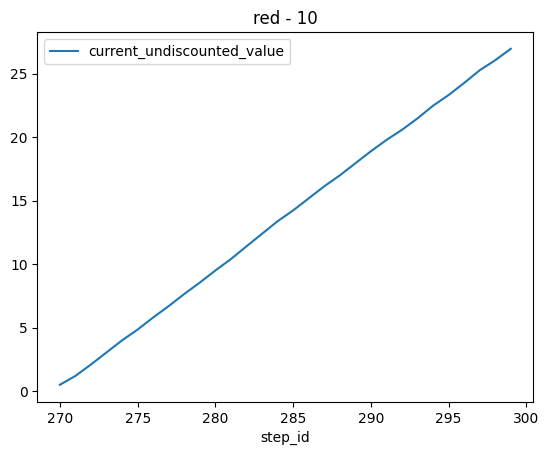

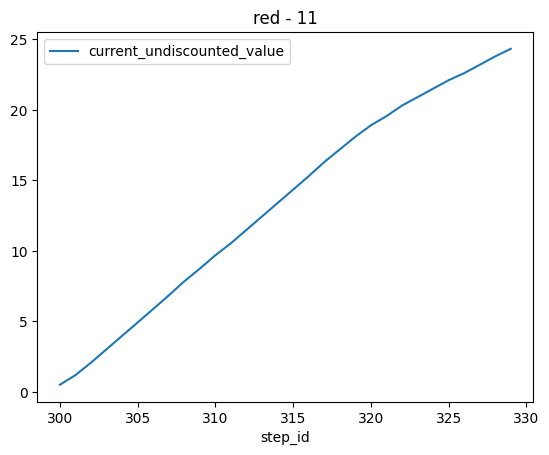

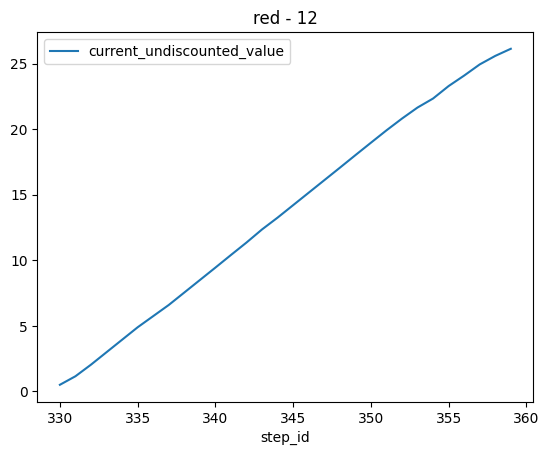

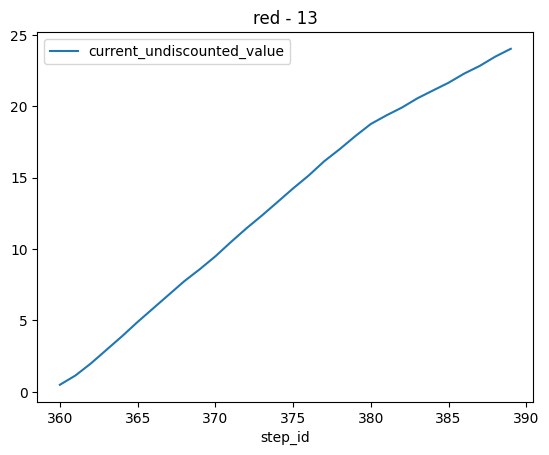

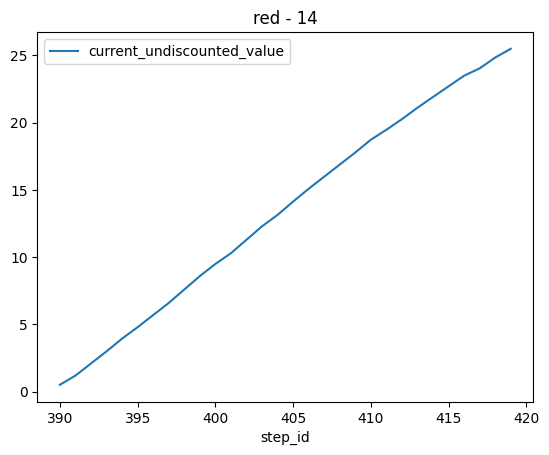

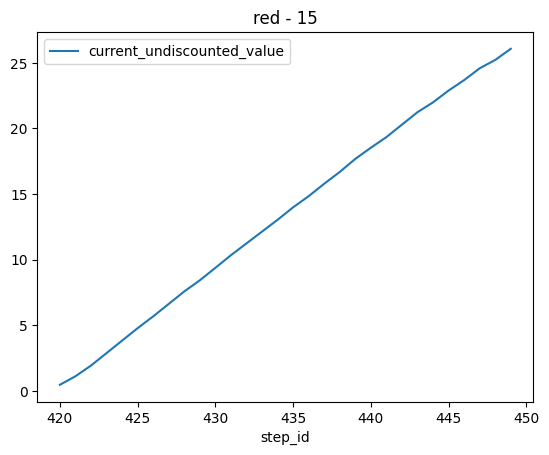

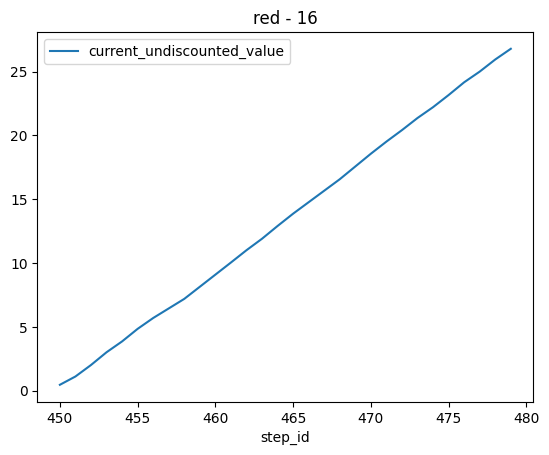

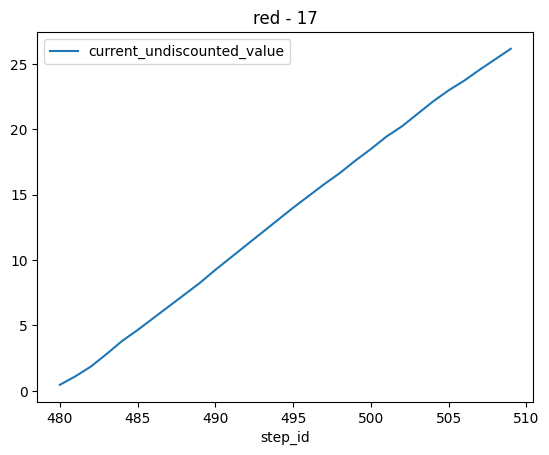

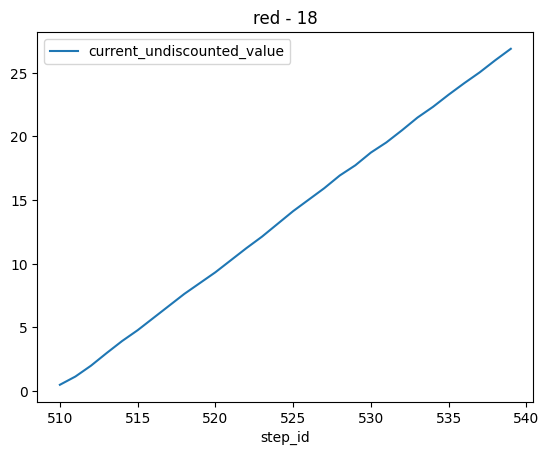

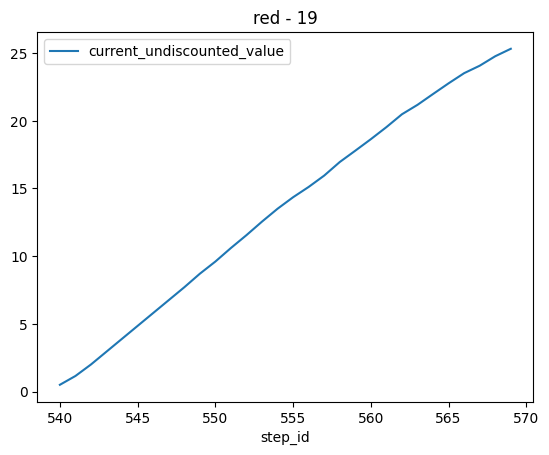

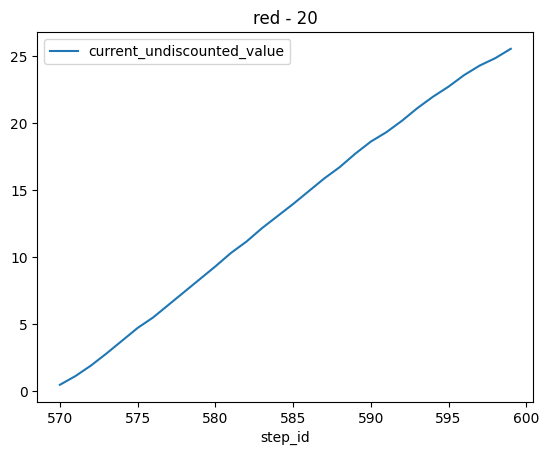

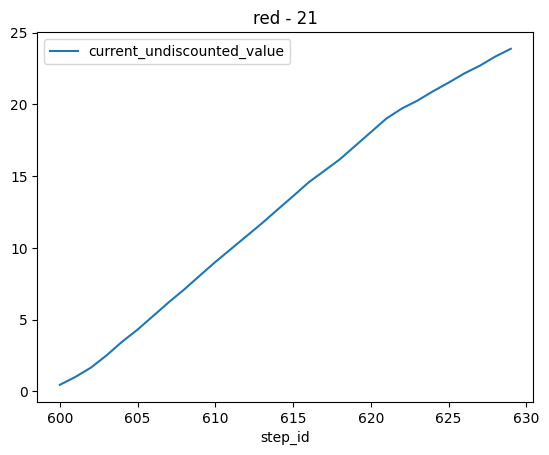

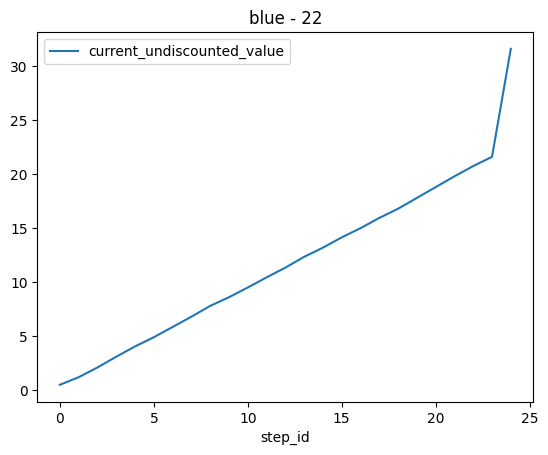

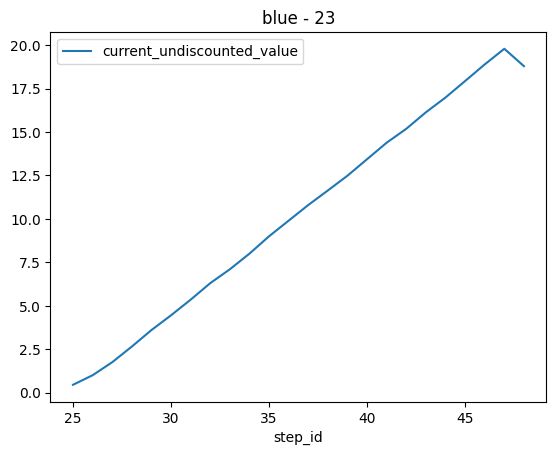

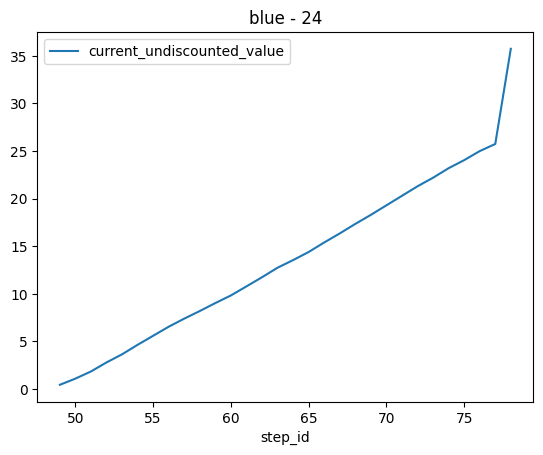

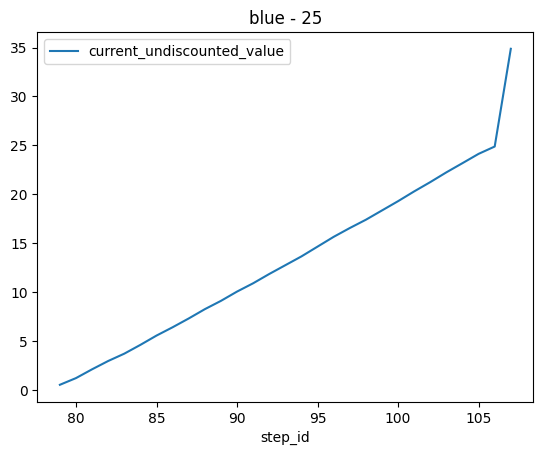

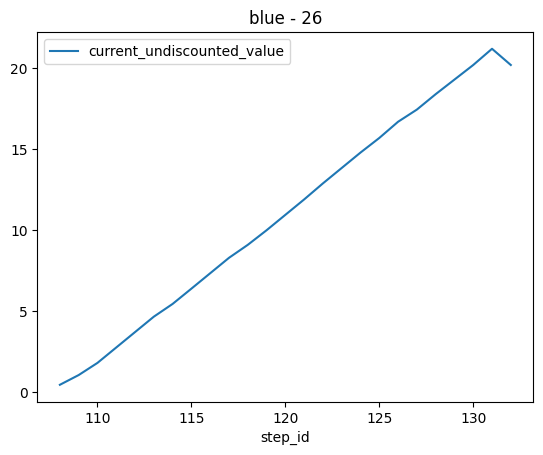

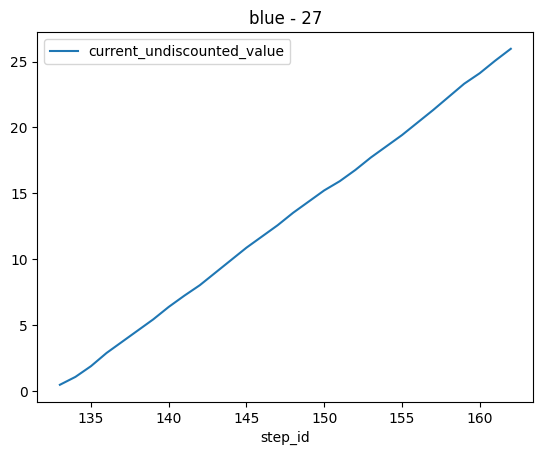

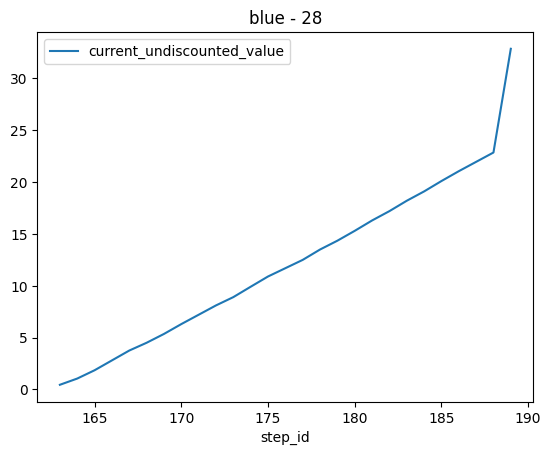

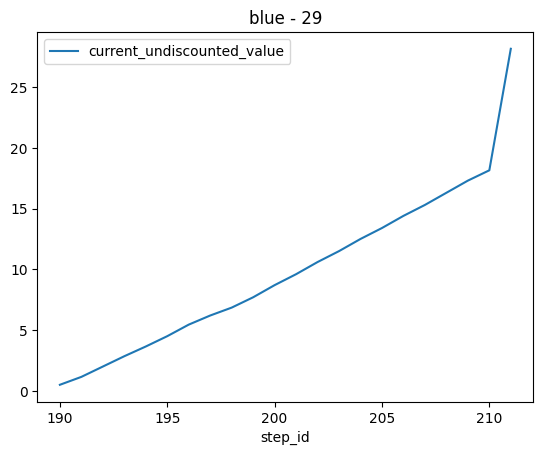

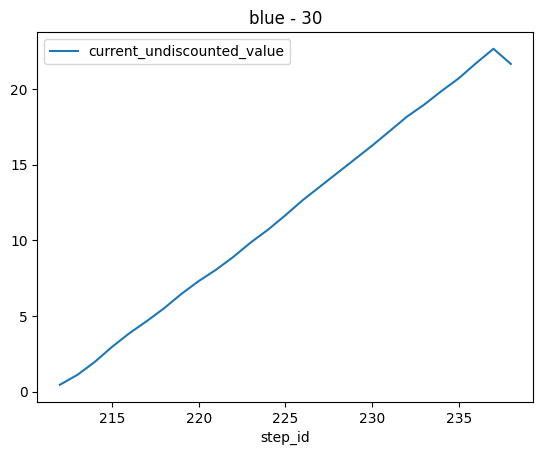

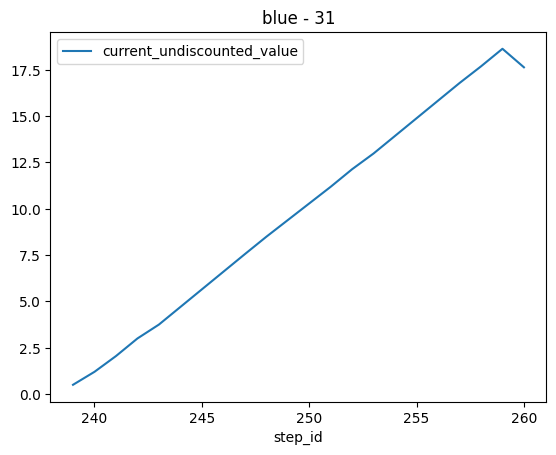

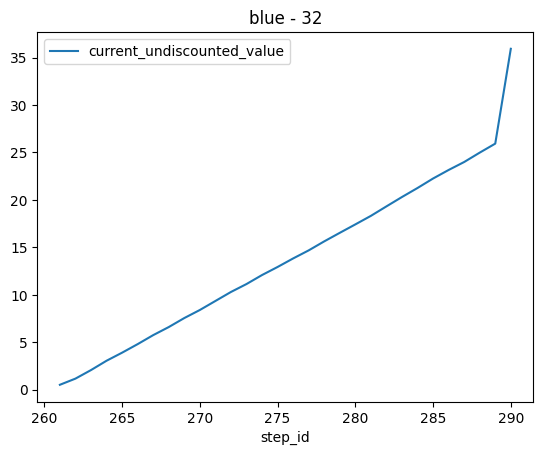

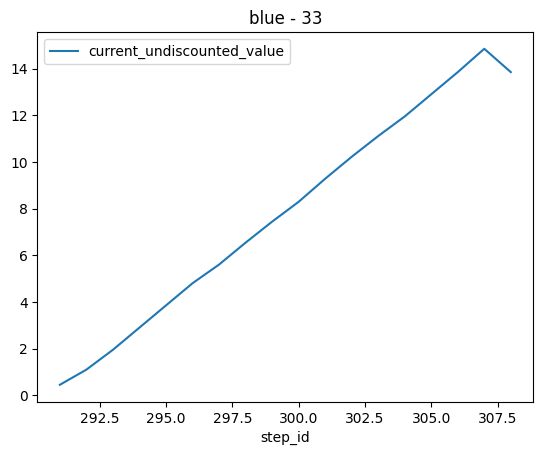

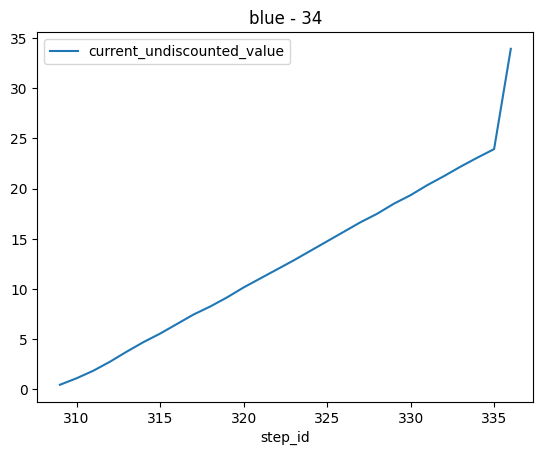

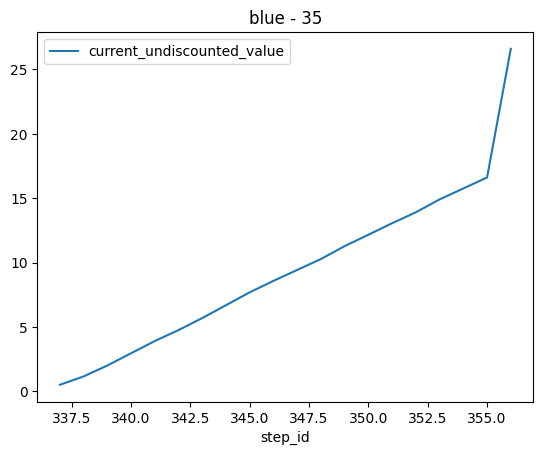

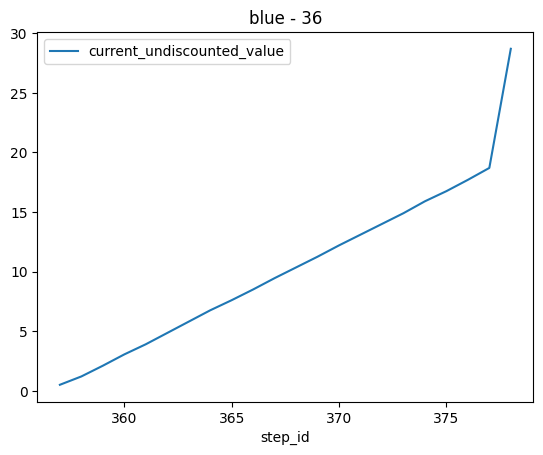

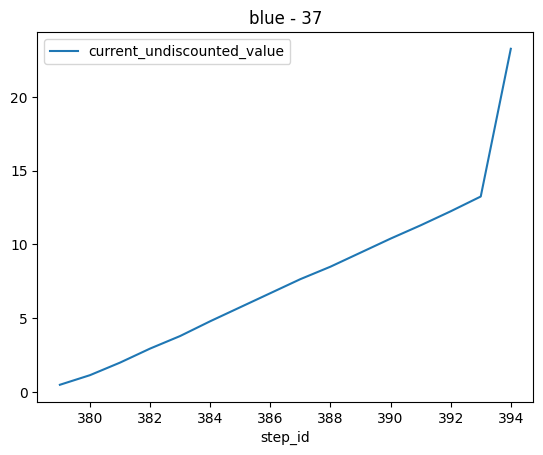

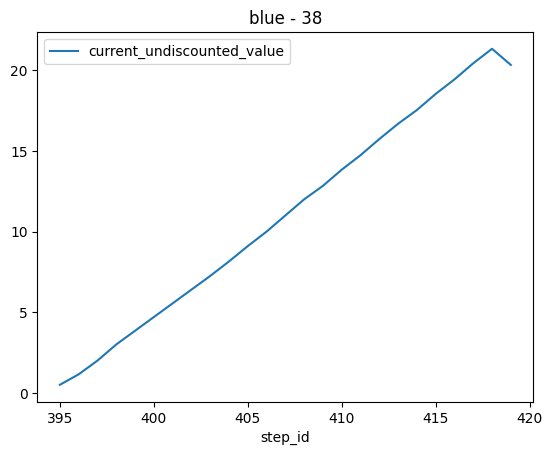

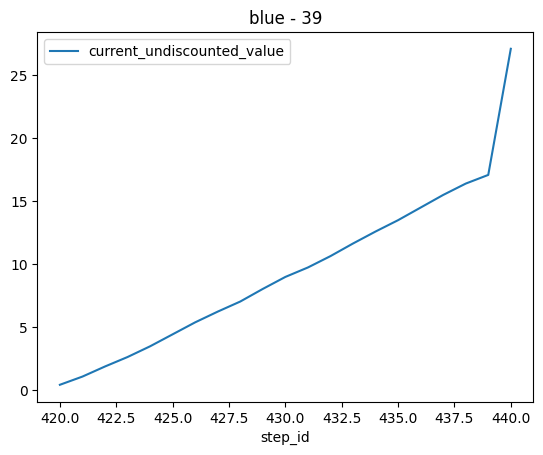

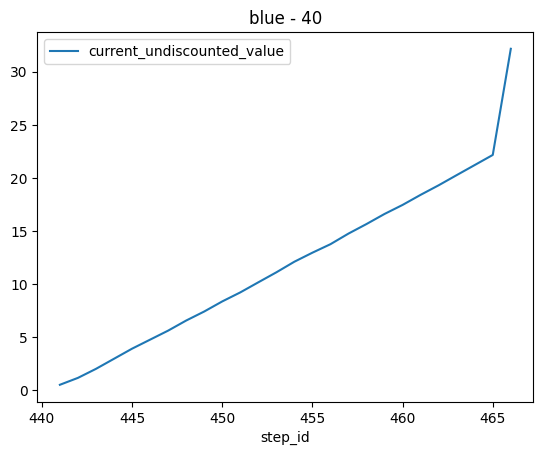

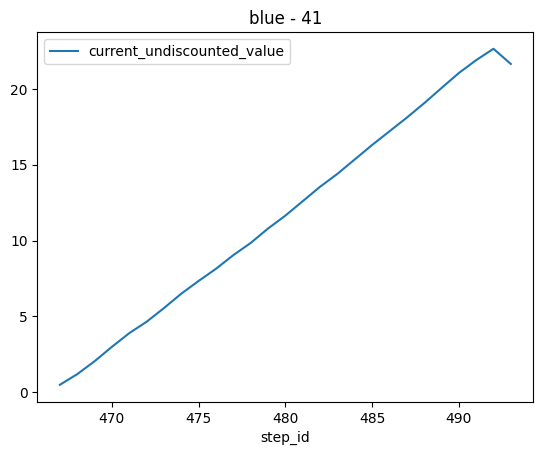

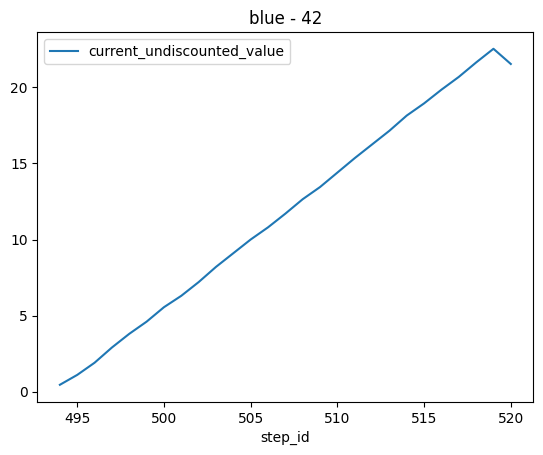

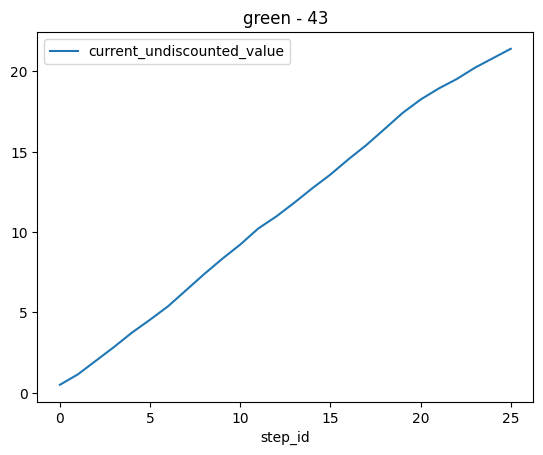

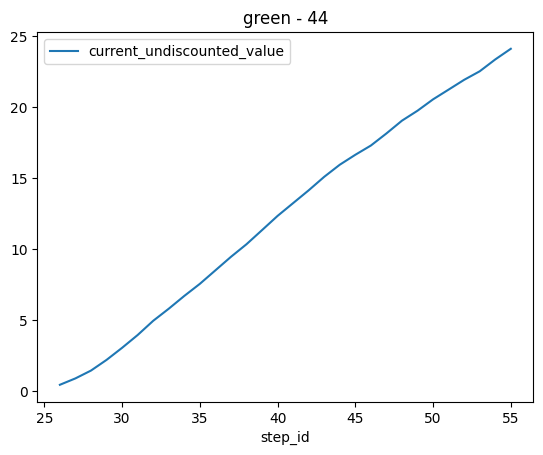

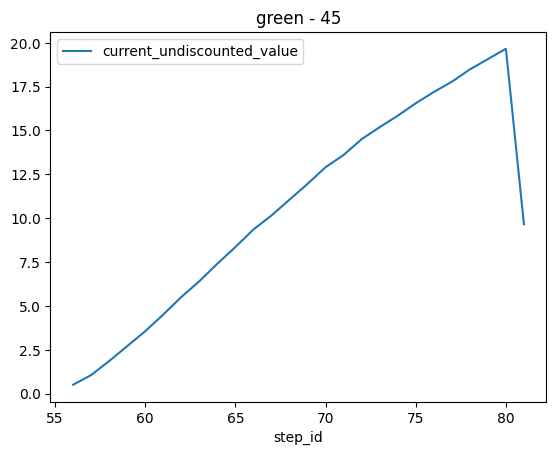

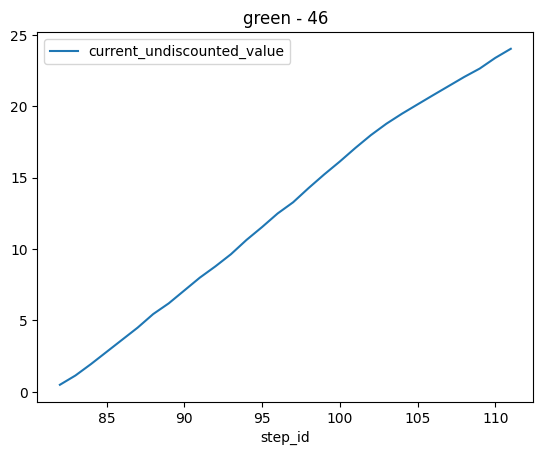

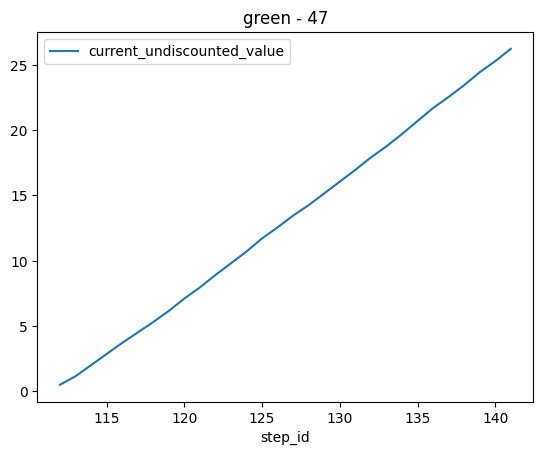

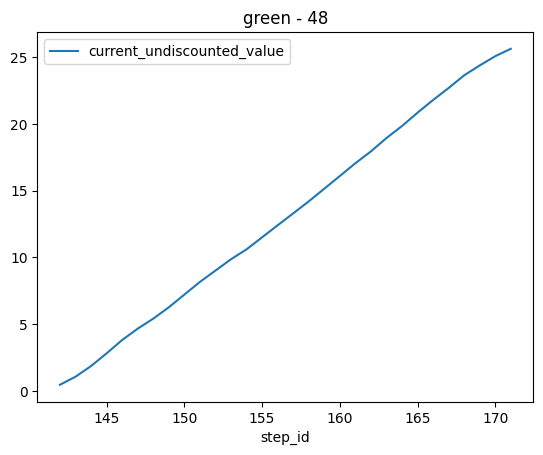

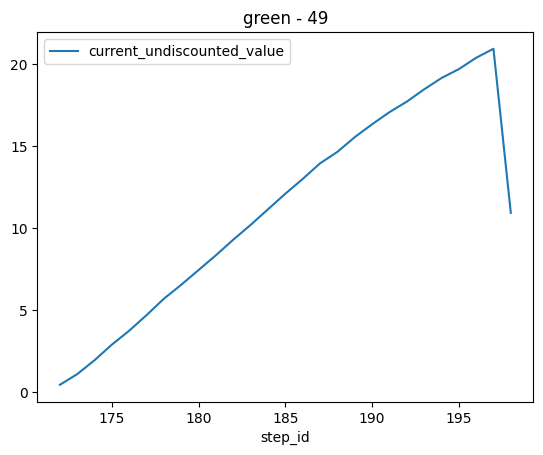

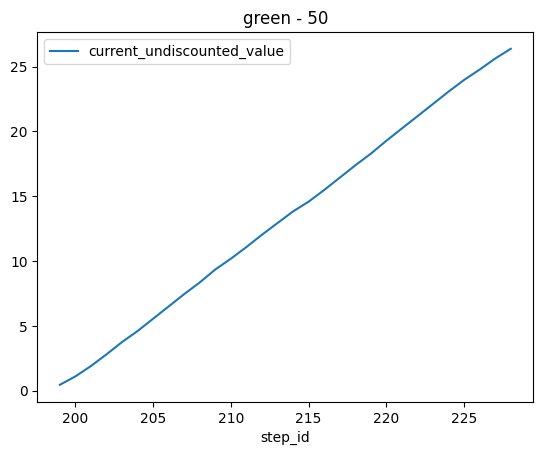

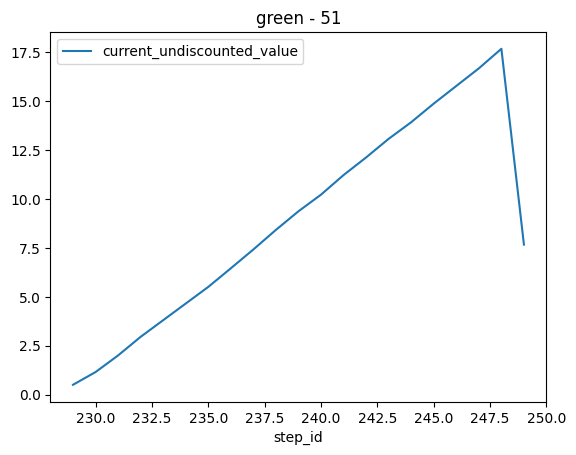

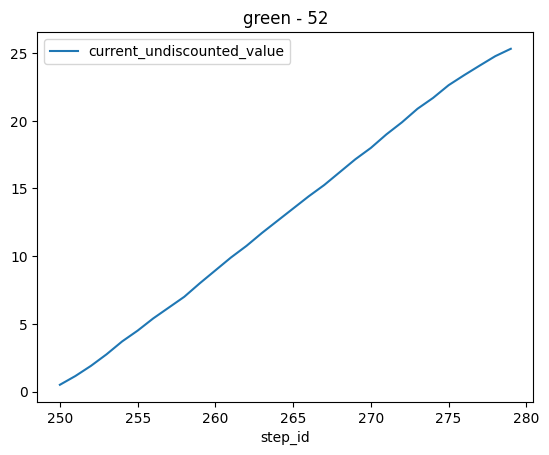

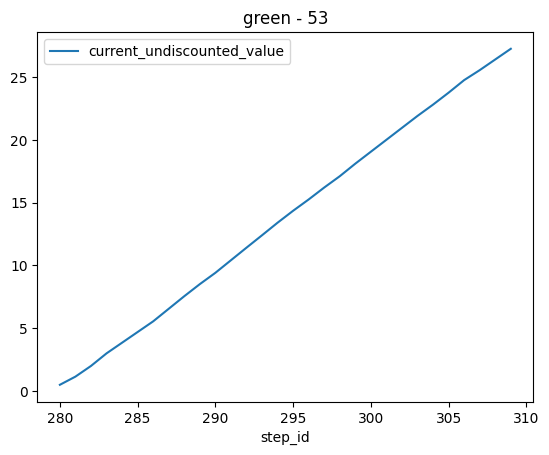

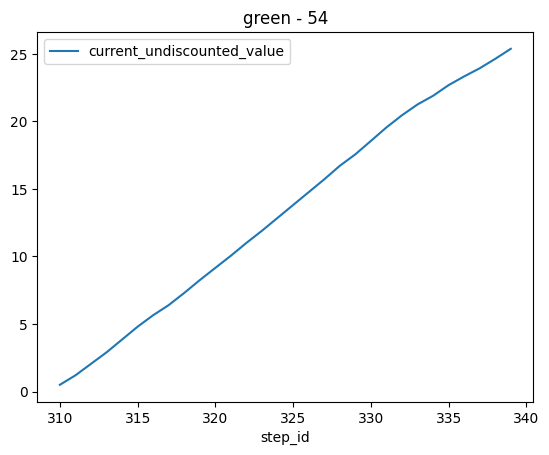

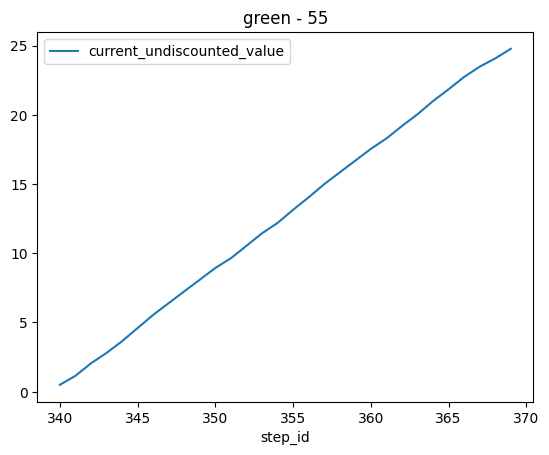

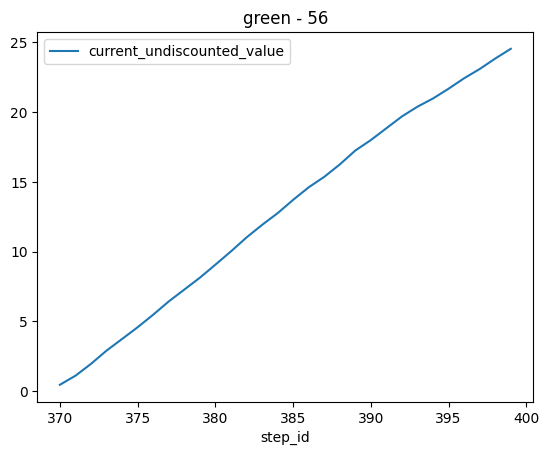

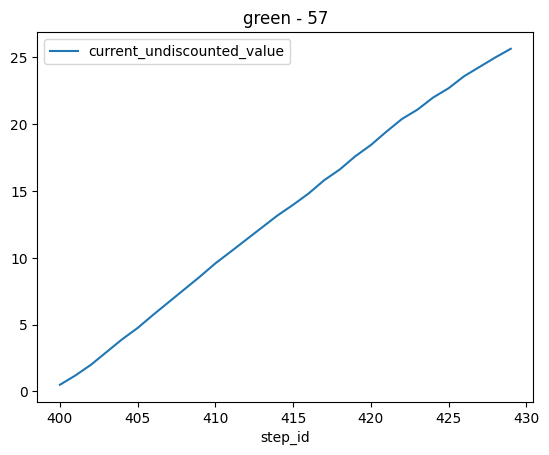

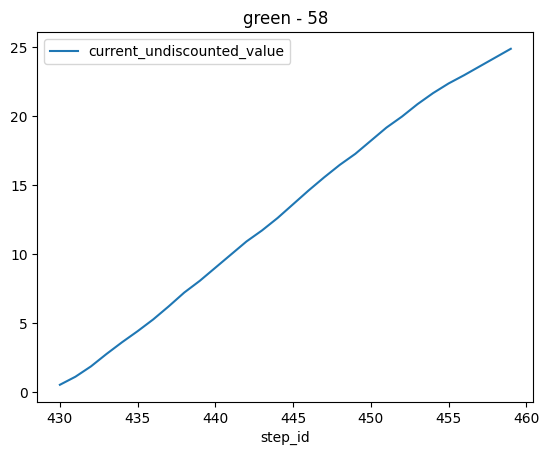

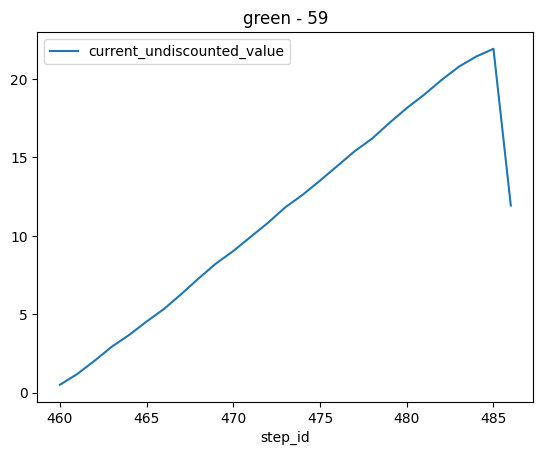

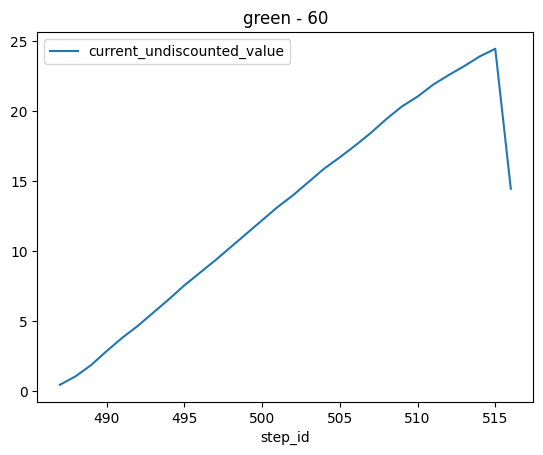

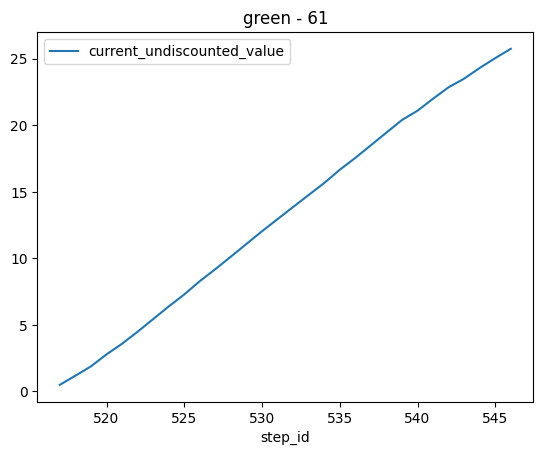

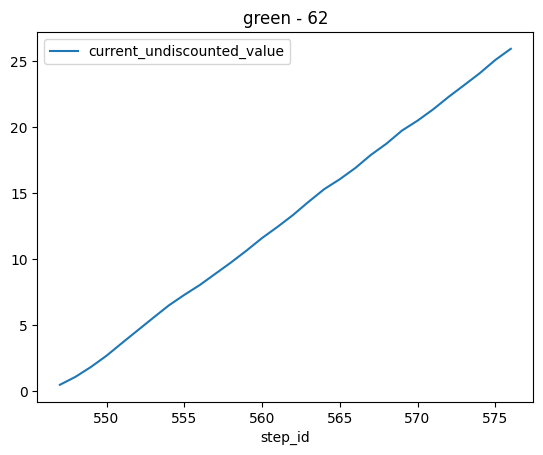

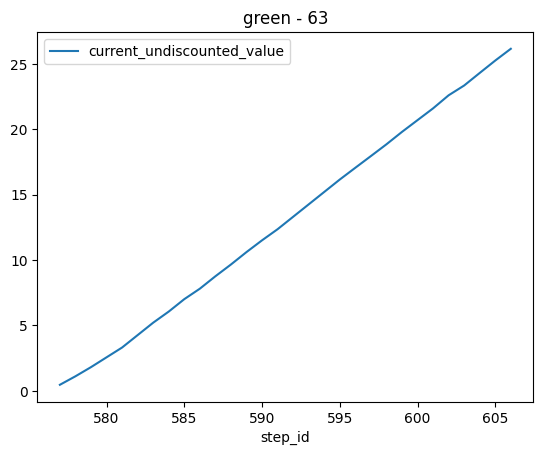

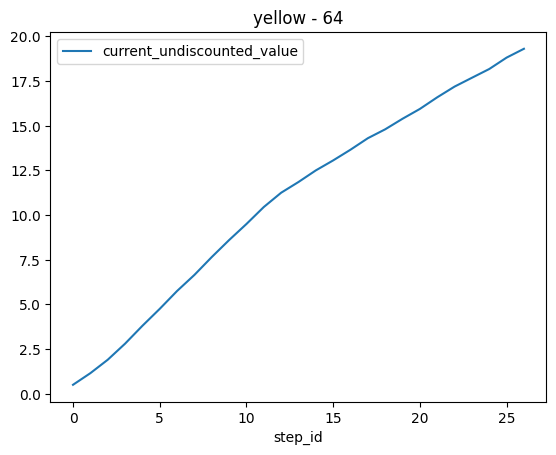

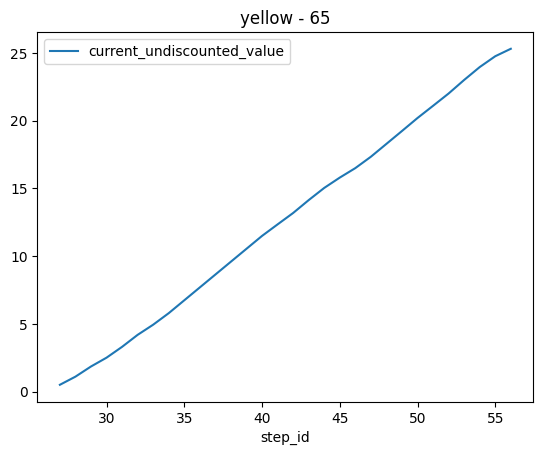

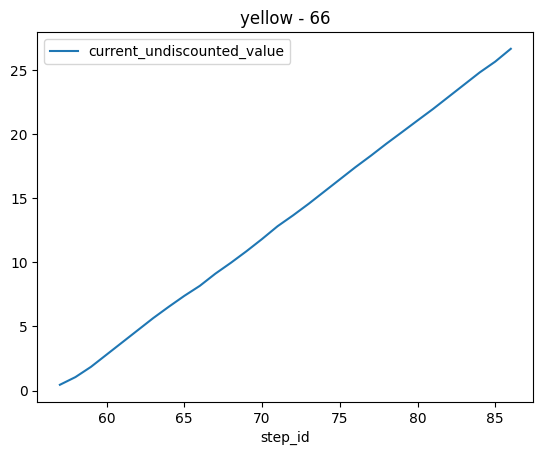

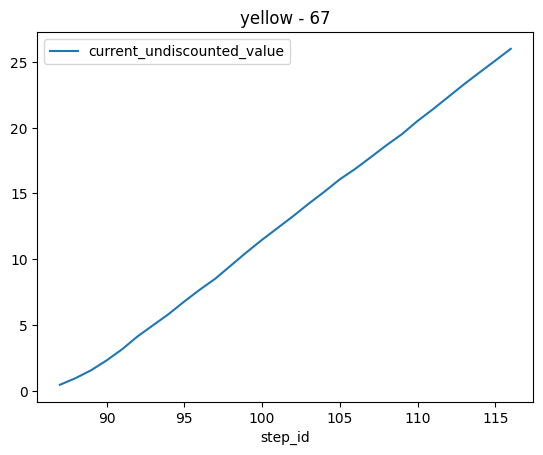

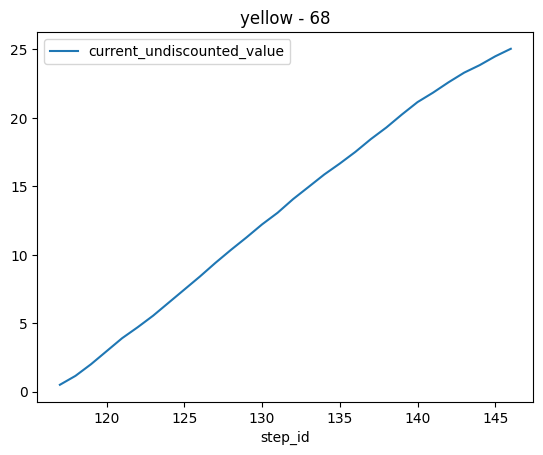

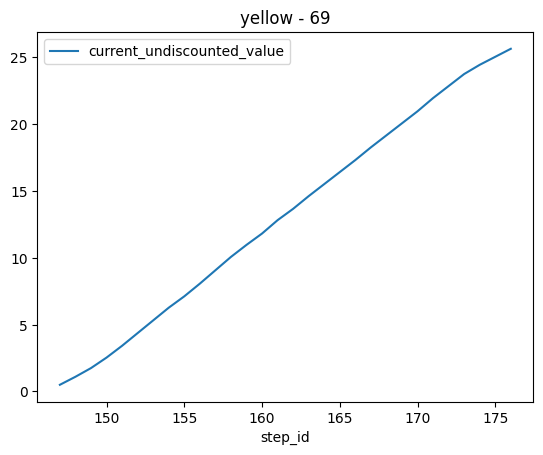

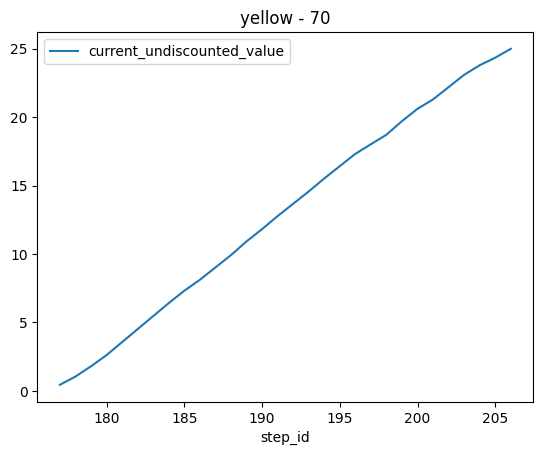

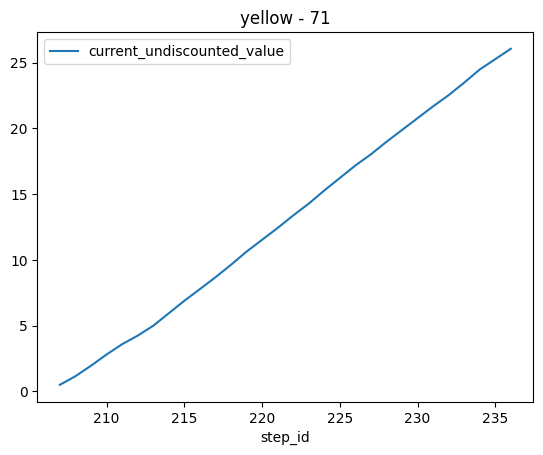

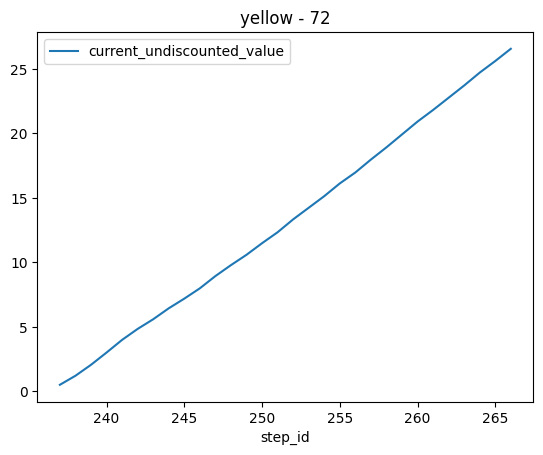

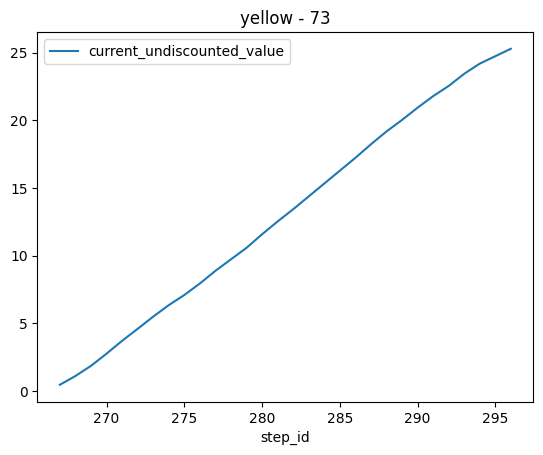

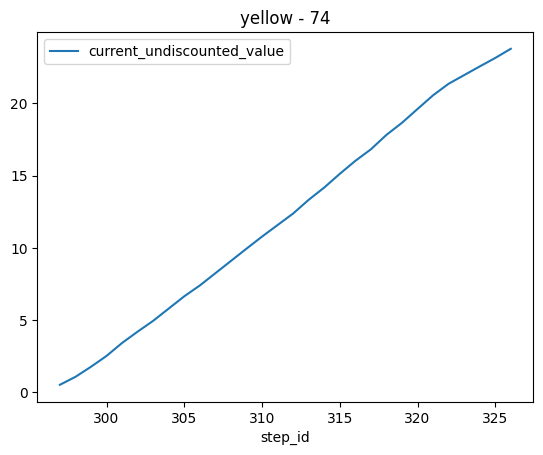

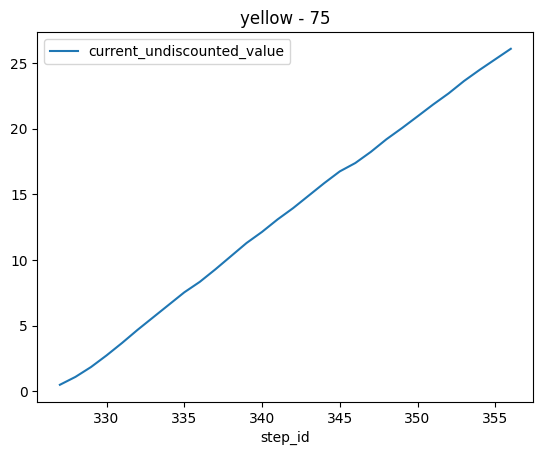

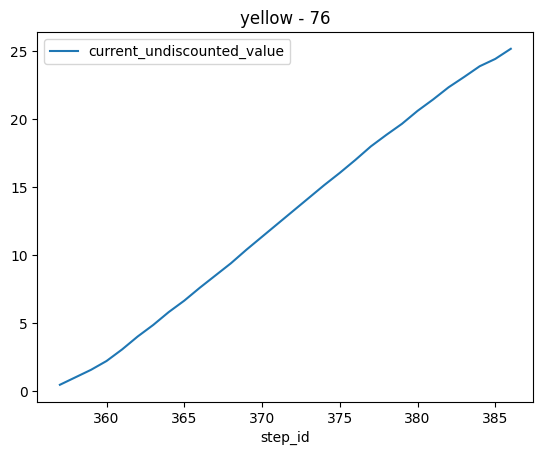

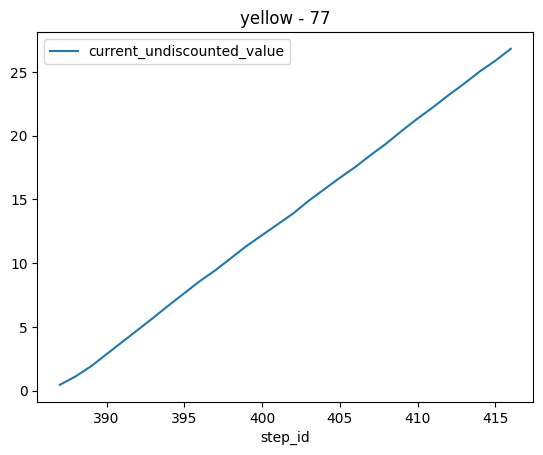

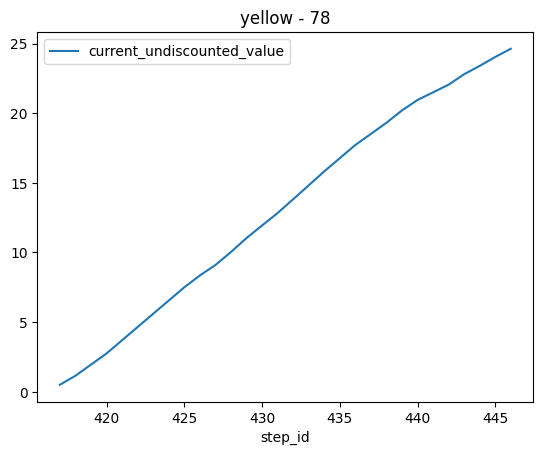

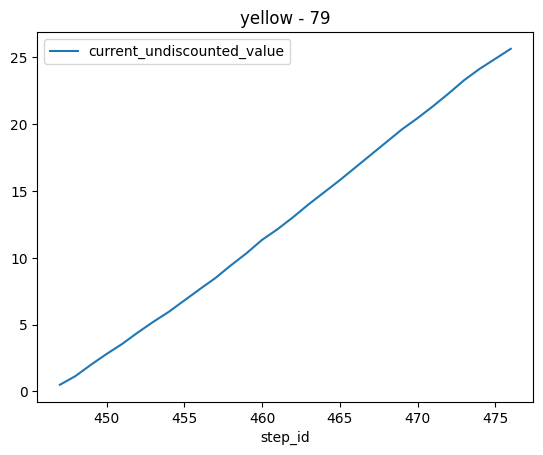

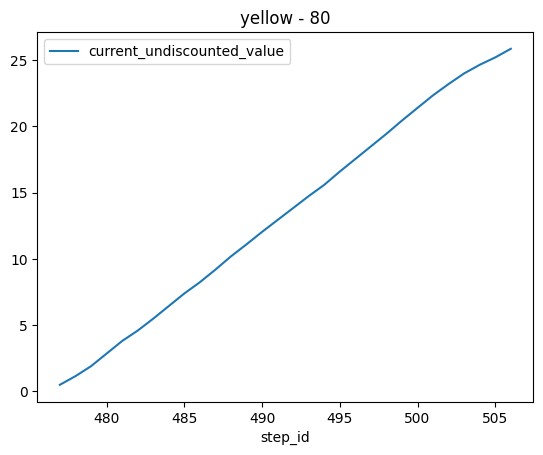

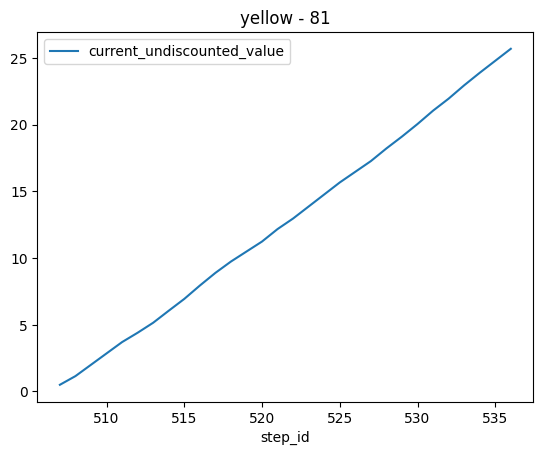

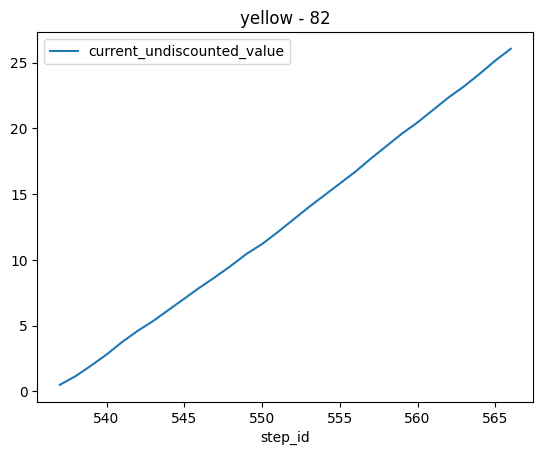

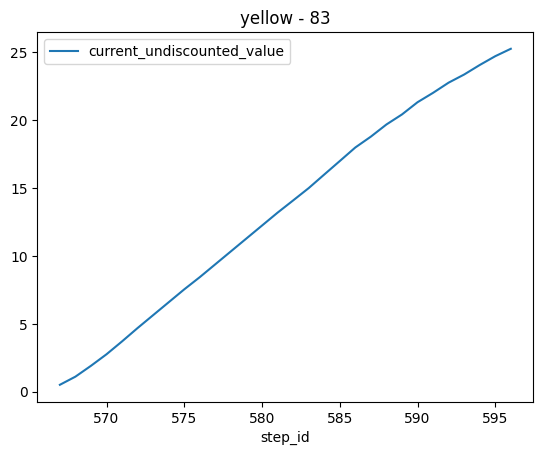

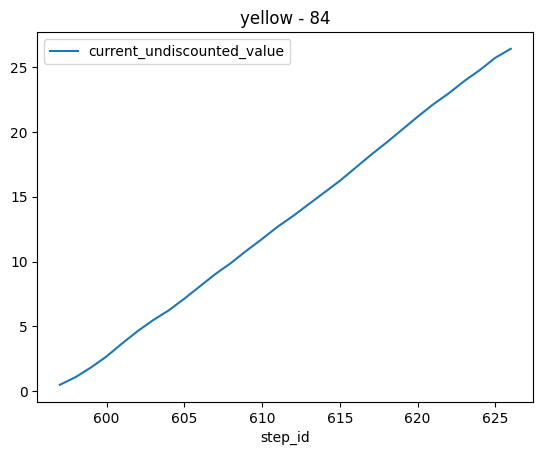

In [ ]:
check_df = tmp_df[tmp_df.phase == "eval"]

for iter in check_df.iteration_id.unique():
    t_df = check_df[check_df.iteration_id == iter]
    t_df.plot(x="step_id", y="current_undiscounted_value", title=f"{t_df.task_name.values[0]} - {t_df.iteration_id.values[0]}")

In [ ]:
[c for c in check_df.columns]

['task_name',
 'index',
 'time',
 'running_objective',
 'current_value',
 'current_undiscounted_value',
 'episode_id',
 'iteration_id',
 'step_id',
 'phase',
 'exploration',
 'Linear Velocity [m/s]',
 'Angular Velocity [rad/s]',
 'Image pixel 0',
 'Image pixel 1',
 'Image pixel 2',
 'Image pixel 3',
 'Image pixel 4',
 'Image pixel 5',
 'Image pixel 6',
 'Image pixel 7',
 'Image pixel 8',
 'Image pixel 9',
 'Image pixel 10',
 'Image pixel 11',
 'Image pixel 12',
 'Image pixel 13',
 'Image pixel 14',
 'Image pixel 15',
 'Image pixel 16',
 'Image pixel 17',
 'Image pixel 18',
 'Image pixel 19',
 'Image pixel 20',
 'Image pixel 21',
 'Image pixel 22',
 'Image pixel 23',
 'Image pixel 24',
 'Image pixel 25',
 'Image pixel 26',
 'Image pixel 27',
 'Image pixel 28',
 'Image pixel 29',
 'Image pixel 30',
 'Image pixel 31',
 'Image pixel 32',
 'Image pixel 33',
 'Image pixel 34',
 'Image pixel 35',
 'Image pixel 36',
 'Image pixel 37',
 'Image pixel 38',
 'Image pixel 39',
 'Image pixel 40',
 '

In [ ]:
check_df = tmp_df[tmp_df.phase == "eval"]

t_df = check_df[check_df.iteration_id == 900]

def plot_eval(df, title):
    plt.figure(figsize=(12, 6))
    ax1 = plt.subplot(1, 2, 1)
    ax1.set_ylabel("Accumulated reward")
    df.plot(x="step_id", y="current_undiscounted_value", title=title, ax=ax1)

    ax2 = plt.subplot(2, 2, 2)
    df.plot(x="time", 
            y="Linear Velocity [m/s]", ax=ax2, color="tab:orange", title="Linear velocity")

    ax3 = plt.subplot(2, 2, 4)
    df.plot(x="time", 
            y="Angular Velocity [rad/s]", ax=ax3, color="tab:blue", title="Angular velocity")

    plt.tight_layout()


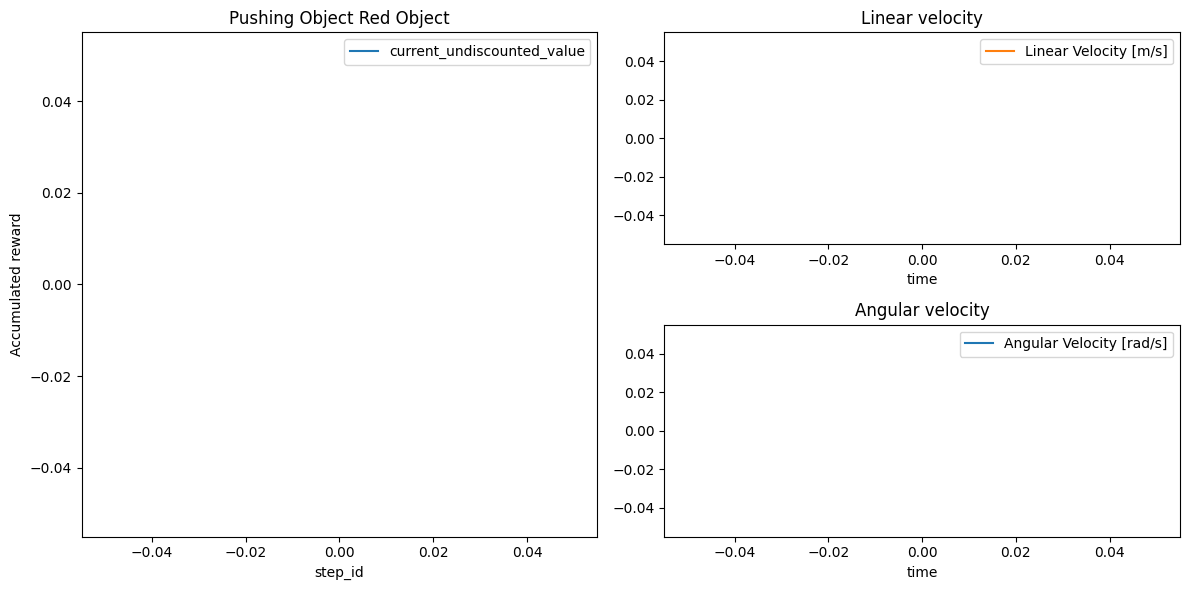

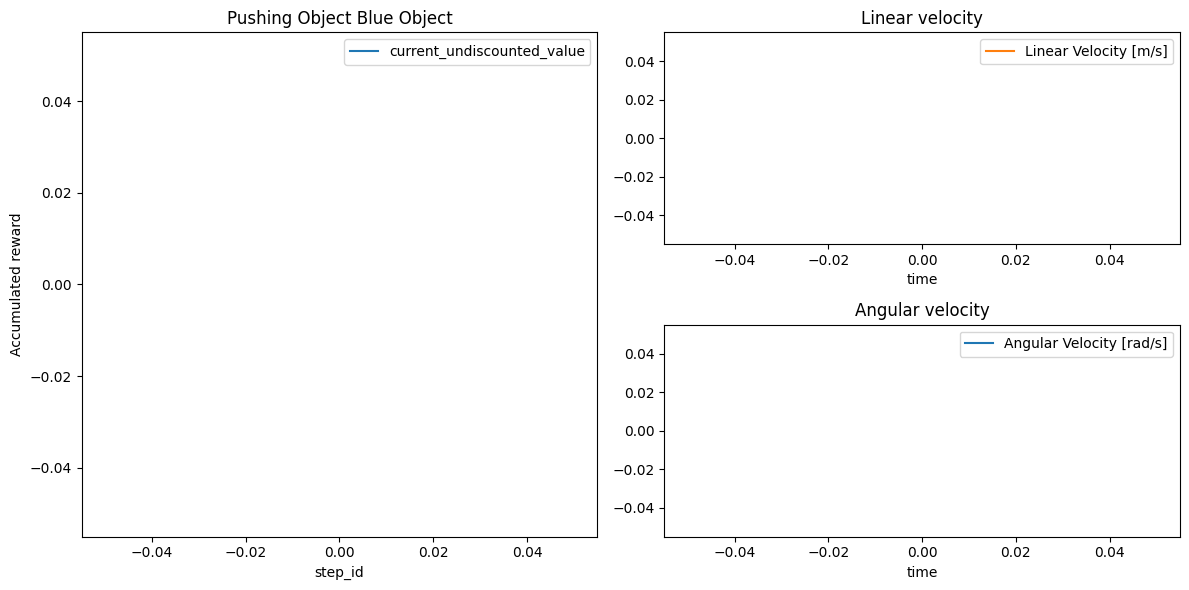

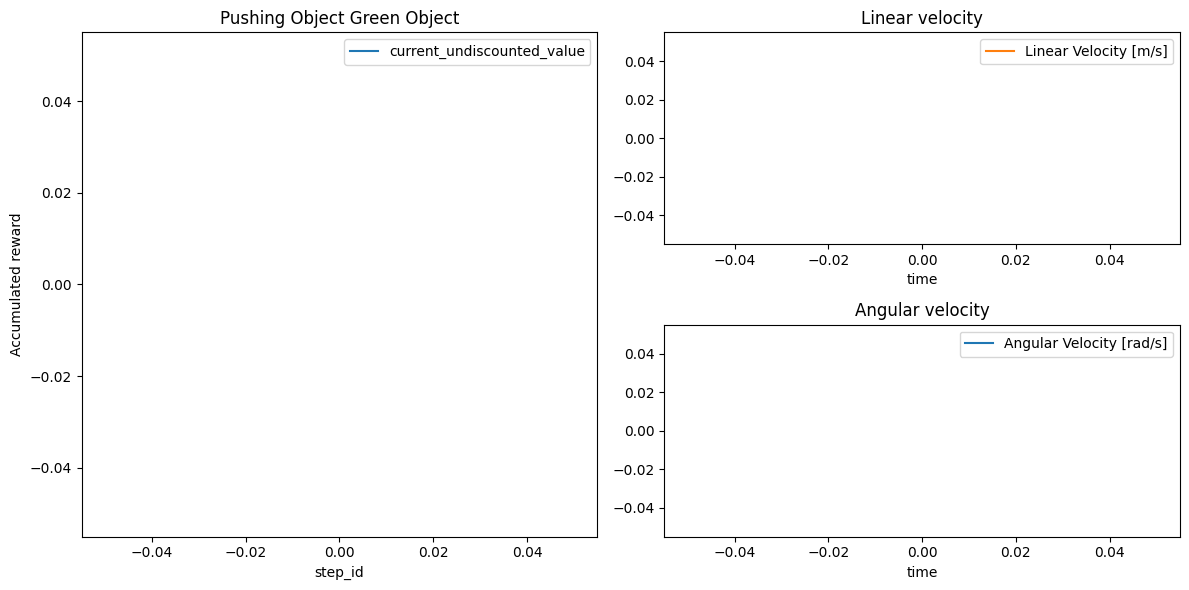

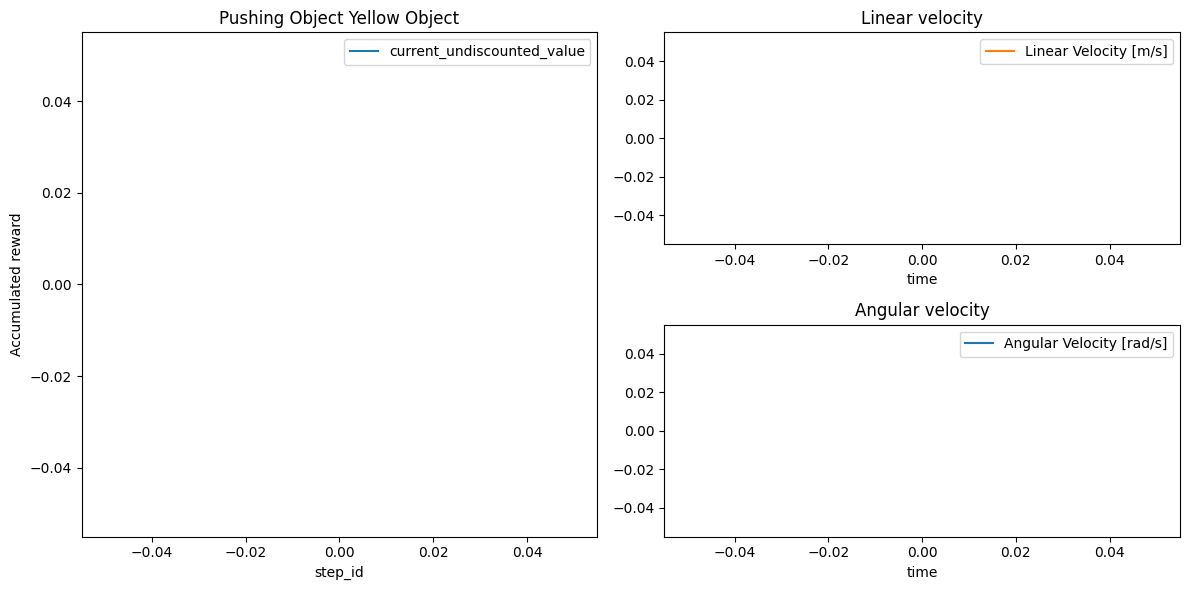

In [ ]:
plot_eval(check_df[check_df.iteration_id == 900], title="Pushing Object Red Object")
plot_eval(check_df[check_df.iteration_id == 903], title="Pushing Object Blue Object")
plot_eval(check_df[check_df.iteration_id == 907], title="Pushing Object Green Object")
plot_eval(check_df[check_df.iteration_id == 913], title="Pushing Object Yellow Object")

In [ ]:
t_df

,,,task_name,index,time,running_objective,current_value,current_undiscounted_value,episode_id,iteration_id,step_id,phase,...,Image pixel 1195,Image pixel 1196,Image pixel 1197,Image pixel 1198,Image pixel 1199,absolute_path,exp_config,experiment_path,is_reset_buffer,learning_starts
controller,category,buffer_size,,,,,,,,,,,,,,,,,,,,,


In [ ]:
check_df

task_name  index   time  \
controller category      buffer_size                           
SAC        PushingObject 16000             red      0  0.000   
                         16000             red      1  0.000   
                         16000             red      2  0.165   
                         16000             red      3  0.330   
                         16000             red      4  0.495   
...                                        ...    ...    ...   
                         16000          yellow     25  3.960   
                         16000          yellow     26  4.125   
                         16000          yellow     27  4.290   
                         16000          yellow     28  4.455   
                         16000          yellow     29  4.620   

                                      running_objective current_value  \
controller category      buffer_size                                    
SAC        PushingObject 16000                 0.500000          None   
                         16000                 0.700000          None   
                         16000                 0.900000          None   
                         16000                 0.950000          None   
                         16000                 0.950000          None   
...                                                 ...           ...   
                         16000                 0.850000          None   
                         16000                 0.950000          None   
                         16000                 0.845545          None   
                         16000                 0.950000          None   
                         16000                 0.696133          None   

                                      current_undiscounted_value  episode_id  \
controller category      buffer_size                                           
SAC        PushingObject 16000                          0.500000           1   
                         16000                          1.200000           1   
                         16000                          2.100000           1   
                         16000                          3.050000           1   
                         16000                          4.000000           1   
...                                                          ...         ...   
                         16000                         22.954210           1   
                         16000                         23.904210           1   
                         16000                         24.749754           1   
                         16000                         25.699754           1   
                         16000                         26.395887           1   

                                      iteration_id  step_id phase  ...  \
controller category      buffer_size                               ...   
SAC        PushingObject 16000                   1        0  eval  ...   
                         16000                   1        1  eval  ...   
                         16000                   1        2  eval  ...   
                         16000                   1        3  eval  ...   
                         16000                   1        4  eval  ...   
...                                            ...      ...   ...  ...   
                         16000                  84      622  eval  ...   
                         16000                  84      623  eval  ...   
                         16000                  84      624  eval  ...   
                         16000                  84      625  eval  ...   
                         16000                  84      626  eval  ...   

                                      Image pixel 1195  Image pixel 1196  \
controller category      buffer_size                                       
SAC        PushingObject 16000                0.423529          0.423529   
                      

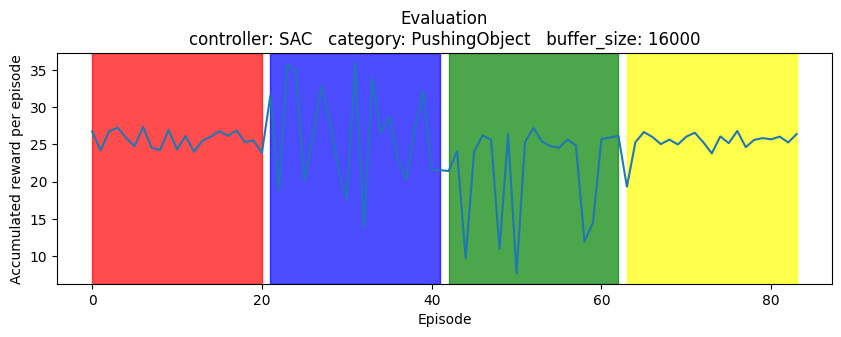

In [ ]:
for id in group_df.index:
    plot_learning_curve(id, group_df.index.names, df[df.phase=="eval"], title="Evaluation")

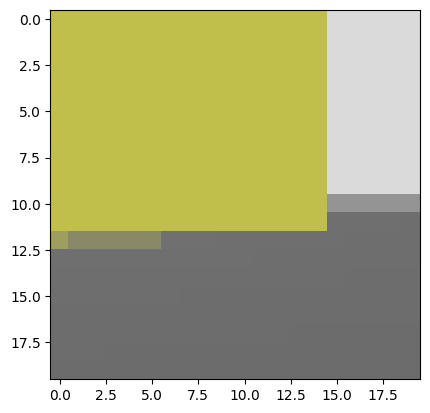

In [ ]:
# df = df.reset_index()
pixel_columns = [c for c in df.columns if "pixel" in c.lower()]
chosen_state = np.array(df.loc[:, pixel_columns].iloc[-1])
im = chosen_state.reshape((20, 20, 3))

plt.imshow(im)

In [ ]:
# from src.objective import RobotPursuitRunningObjective

# objective_func = RobotPursuitRunningObjective()

# objective_func(state=im, 
#                catcher_pos=[1, 1], 
#                runner_pos=[0, 0], 
#                action=[1, 0], 
#                step_count=0, 
#                max_steps_per_episode=100,
#                runner_collision_thickness=0.49,
#                arena_bounds=[-2.5,2.5,-2.5,2.5],
#                info={})

In [ ]:
import numpy as np
np.sum(im)

671.5725

KeyError: ('SAC', 'LineFollowing', False)

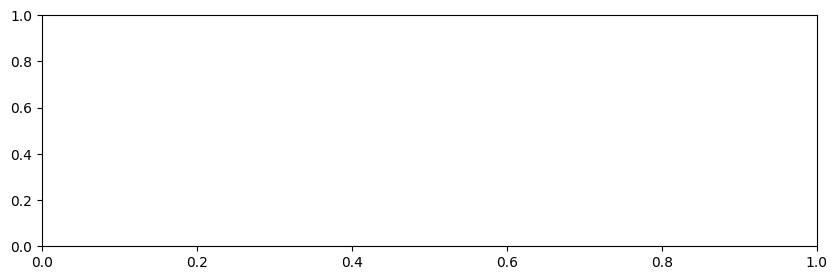

In [ ]:
plot_learning_curve(('SAC', 'LineFollowing', False), group_df.index.names, df)
plot_learning_curve(('SAC', 'LineFollowing', True), group_df.index.names, df)

In [ ]:
tmp_df["previous_step"] = [tmp_df.step_id.values.tolist()[0]] + tmp_df.step_id.values.tolist()[:-1]
tmp_df[(tmp_df.step_id.diff() < 0)]
# tmp_df.step_id.values.tolist()[1:]+ [tmp_df.step_id.values.tolist()[-1]]

/tmp/ipykernel_127043/3476527340.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp_df["previous_step"] = [tmp_df.step_id.values.tolist()[0]] + tmp_df.step_id.values.tolist()[:-1]


index   time  running_objective  \
controller category      is_reset_buffer                                    
SAC        LineFollowing False                6  0.000           0.408163   
                         False                8  0.198           0.000000   
                         False                9  0.363           0.000000   
                         False               10  0.528           0.000000   
                         False               11  0.693           0.000000   
                         False                2  0.000           0.693878   
                         False               15  0.000           0.734694   
                         False               18  0.363           0.979592   
                         False               19  0.528           0.979592   
                         False               20  0.693           0.897959   
                         False               21  0.858           0.775510   
                         False               22  1.023           0.530612   
                         False               23  1.188           0.285714   
                         False               24  1.353           0.081633   
                         False               25  1.518           0.040816   
                         False               26  1.683          -1.000000   
                         False                0  0.000           0.530612   

                                         current_value  \
controller category      is_reset_buffer                 
SAC        LineFollowing False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   

                                          current_undiscounted_value  \
controller category      is_reset_buffer                               
SAC        LineFollowing False                              2.693878   
                         False                              2.857143   
                         False                              2.857143   
                         False                              2.857143   
                         False                              2.857143   
                         False                              2.122449   
                         False                              5.755102   
                         False                              8.448980   
                         False                              9.428571   
                         False                             10.326531   
                         False                             11.102041   
                         False                             11.632653   
                         False                             11.918367   
                         False                             12.000000   
                         False                             12.040816   
                         False                             11.040816   
                         False                              0.530612   

                                          episode_id  iteration_id  \
controller category      is_reset_bu

In [ ]:
tmp_df[tmp_df.iteration_id == 1196]

index   time  running_objective  \
controller category      is_reset_buffer                                    
SAC        LineFollowing False                0  0.000           0.693878   
                         False                1  0.000           0.857143   
                         False               15  0.000           0.734694   
                         False               16  0.000           0.775510   
                         False               17  0.165           0.938776   
                         False                2  0.198           0.979592   
                         False                3  0.363           0.775510   
                         False               18  0.363           0.979592   
                         False                4  0.528           0.408163   
                         False               19  0.528           0.979592   
                         False                5  0.693           0.448980   
                         False               20  0.693           0.897959   
                         False                6  0.858           0.326531   
                         False               21  0.858           0.775510   
                         False                7  1.023           0.122449   
                         False               22  1.023           0.530612   
                         False                8  1.188           0.040816   
                         False               23  1.188           0.285714   
                         False                9  1.353           0.040816   
                         False               24  1.353           0.081633   
                         False               10  1.518           0.040816   
                         False               25  1.518           0.040816   
                         False               11  1.683           0.000000   
                         False               26  1.683          -1.000000   
                         False               12  1.848           0.081633   
                         False               13  2.013           0.081633   
                         False               14  2.178           0.122449   

                                         current_value  \
controller category      is_reset_buffer                 
SAC        LineFollowing False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   

                                          current_undiscounted_value  \
controller category      is_reset_buffer             